In [1]:
import sys
from pathlib import Path
import matplotlib.pyplot as plt

HERE = Path().resolve()
PROJECT_ROOT = next(p for p in [HERE, *HERE.parents] if (p / "src").exists())
sys.path.insert(0, str(PROJECT_ROOT)) 
# ^finds project root relative to device

#print("cwd:", HERE)
#print("project root:", PROJECT_ROOT)
#print("src path:", PROJECT_ROOT / "src")

In [2]:
#PROJECT_ROOT = Path(r"C:\Users\alNM3\Desktop\DRIVESIM OFFICIAL CLONE LOCATION\DriveSim-AI-Lboro-Group")
#print((PROJECT_ROOT / "src" / "__init__.py").exists(), PROJECT_ROOT / "src" / "__init__.py")

In [3]:
from src.io.obd_loader import load_obd_csv, require_columns
from src.io.timebase import add_elapsed_time
from src.physics.kinematics import add_speed_ms, add_acceleration
from src.physics.longitudinal import VehicleParams, add_longitudinal_forces
from src.physics.power_energy import add_power_terms, add_energy_terms

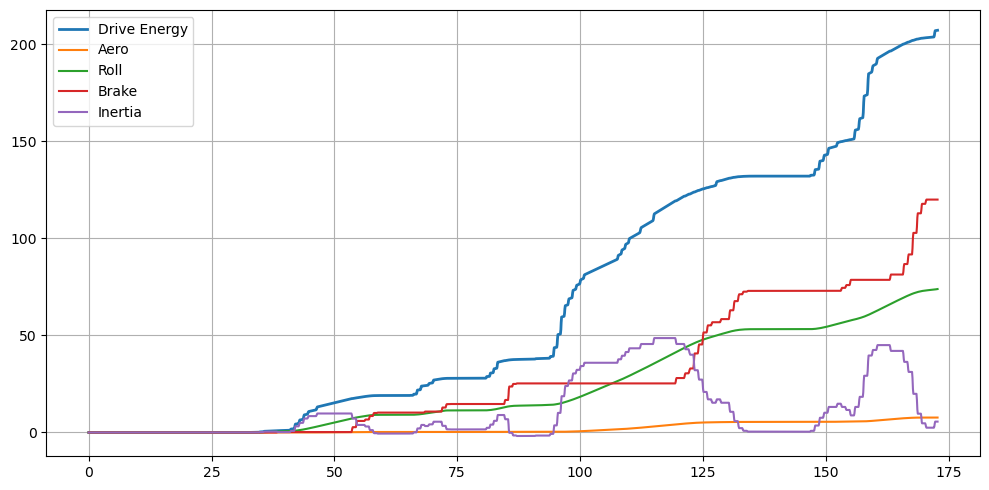

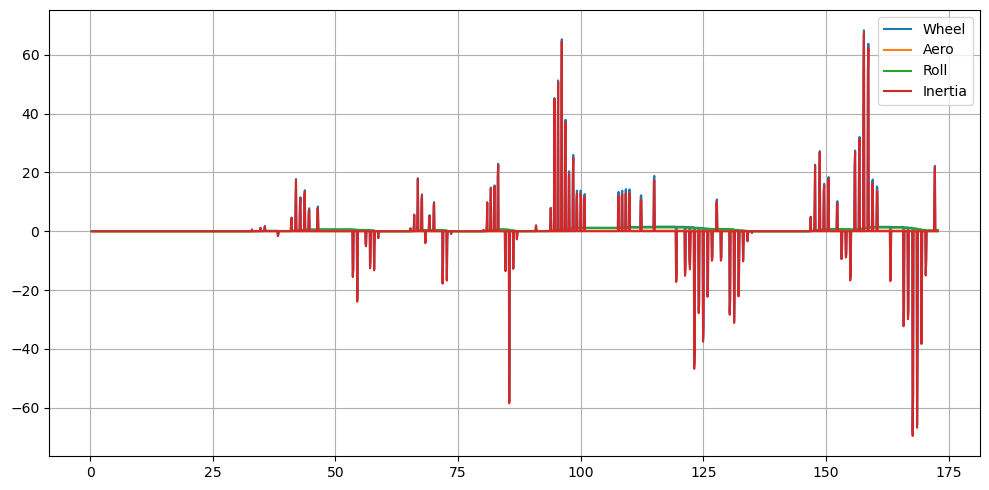

In [4]:
df = load_obd_csv(PROJECT_ROOT/"data/KIT/2017-07-05_Seat_Leon_RT_S_Stau.csv")
require_columns(df, ["time", "speed_kmh", "engine_rpm"])

df = add_elapsed_time(df)
df = add_speed_ms(df)
df = add_acceleration(df)

params = VehicleParams(
    mass_kg=1300, Cd=0.3, area_m2=2.2, crr=0.012,
    tyre_radius_m=0.318, rho_air=1.17
)

df = add_longitudinal_forces(df, params, grade_rad=0.0)
df = add_power_terms(df)
df = add_energy_terms(df)

sub = df.iloc[:2000].copy()

plt.figure(figsize=(10,5))
plt.plot(sub["elapsed_time_s"], sub["E_drive_kJ"], label="Drive Energy", linewidth=2)
plt.plot(sub["elapsed_time_s"], sub["E_aero_kJ"], label="Aero")
plt.plot(sub["elapsed_time_s"], sub["E_roll_kJ"], label="Roll")
plt.plot(sub["elapsed_time_s"], sub["E_brake_kJ"], label="Brake")
plt.plot(sub["elapsed_time_s"], sub["E_inertia_kJ"], label="Inertia")
plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

plt.figure(figsize=(10,5))
plt.plot(sub["elapsed_time_s"], sub["P_wheel_W"]/1000, label="Wheel")
plt.plot(sub["elapsed_time_s"], sub["P_aero_W"]/1000, label="Aero")
plt.plot(sub["elapsed_time_s"], sub["P_roll_W"]/1000, label="Roll")
plt.plot(sub["elapsed_time_s"], sub["P_inertia_W"]/1000, label="Inertia")
plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()
